# SAMI — Notebook 1 · Input & user profile

**Exploratory data analysis — "what data do we have, and who is the audience?"**
This notebook is deliberately descriptive: one variable at a time, no cross-cuts,
no time axis, no thematic reading. It answers two questions before any figure is
over-interpreted.

**Block A · The input.** What sources exist (chatbot *responses* + the *MEAL*
survey), how many records and users each holds, and how complete and reliable
they are.

**Block B · The general profile.** Who the audience is — sociodemographics
(nationality, gender, age, care responsibilities), geography (where users are),
and the migration journey they describe (time away, origin → onward destination).

---

### Objectives
- **Characterize the input.** Establish what data exists — size, columns,
  completeness and quality of each source — before reading any figure.
- **Profile the audience.** Describe *who* the users are and *where they are
  located*, combining the variables needed for a clear picture (maps, descriptive
  breakdowns), without yet looking for causal or strategic relationships.

### Guiding questions
1. What is Sami, which data sources do we have, and how reliable are they?
2. Who is the audience — sociodemographically and geographically — and what
   migration journey does it describe?

### Hypotheses
- **H1.** The dataset has fields with high missingness, but mostly *expected*
  (conditional `*_other` free-text fields that only apply to a subset).
- **H2.** The typical user is young, mostly Venezuelan, concentrated in a few
  cities, with a visible mix of recent arrivals and settled residents.
- **H3.** The migration pattern is a predominant Venezuela → Colombia inflow,
  with a smaller onward dispersion to other countries.

## Setup

In [1]:
# Imports. Collapsed on purpose -- no analysis here.
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LogNorm
from scipy.stats import gaussian_kde

# Geo stack -- both maps use cartopy with Natural Earth data (downloaded & cached
# on first run): Section 3 = Colombia department choropleth (admin-1), Section 4
# = Americas nationality choropleth (admin-0) + onward-migration routes.
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.io import shapereader
from shapely.ops import unary_union       # dissolve departments -> national border
from adjustText import adjust_text        # repel overlapping map labels

In [2]:
# ---- Brand palette -----------------------------------------------------------
# Official SAMI colours. Blue ("agua") is the workhorse: every magnitude chart
# uses PRIMARY or the BLUE_CMAP ramp (light -> dark = small -> large). The three
# accent hues carry identity where slices are genuinely different things; "madera"
# doubles as the neutral for residual "other / prefer not" categories. Re-theme
# the whole notebook by editing THIS cell only.
from matplotlib.colors import LinearSegmentedColormap

COLORES = {
    "agua":   "#6281DA",   # brand blue (primary)
    "madera": "#8E8E78",   # olive-grey (neutral)
    "hongo":  "#E0DDDC",   # warm light grey (grid / tracks)
    "negro":  "#000000",
    "cielo":  "#EFEFEF",   # light grey (soft surface)
    "ameba":  "#D5A9EA",   # lilac (accent)
    "arbol":  "#6E8149",   # green (accent)
}

PRIMARY  = COLORES["agua"]
DARKBLUE = "#26386e"       # darker blue for line/border EMPHASIS only -- the gradient itself tops at brand blue
BLUE_CMAP = LinearSegmentedColormap.from_list(   # light -> dark blue, anchored on agua
    "sami_agua", ["#f2f5fc", "#d9e1f6", "#bdcaf0", "#9db1e8", "#819ae1", "#6281DA"])

def seq_colors(n, lo=0.30, hi=1.0):
    """n blues, light->dark, for an ordered magnitude (small->large)."""
    if n == 1:
        return [PRIMARY]
    return [BLUE_CMAP(lo + (hi - lo) * i / (n - 1)) for i in range(n)]

def seq_by_value(values, lo=0.30, hi=1.0):
    """One blue per value, shade scaled to the value itself (min->max)."""
    v = np.asarray(values, dtype=float)
    if v.max() == v.min():
        return [PRIMARY] * len(v)
    t = (v - v.min()) / (v.max() - v.min())
    return [BLUE_CMAP(lo + (hi - lo) * ti) for ti in t]

BLUE_SEQ = seq_colors(6)                  # legacy alias: a few ordered blues

# Categorical identity set, fixed order: agua / arbol / ameba, then madera as the
# neutral for a residual category. Never cycle a 5th hue -- fold extras into madera.
CAT = [COLORES["agua"], COLORES["arbol"], COLORES["ameba"], COLORES["madera"]]
NEUTRAL = COLORES["madera"]
EARTH = CAT

def cat_colors(n):
    """n distinct categorical colors (fixed order, no cycling past the set)."""
    if n > len(CAT):
        return CAT[:-1] + [NEUTRAL] * (n - len(CAT) + 1)
    return CAT[:n]

# Text / structure tokens.
INK   = COLORES["negro"]
INK2  = "#4d4d4d"
MUTED = COLORES["madera"]
GRID  = COLORES["hongo"]
SURFACE = "white"

def pct_only_autopct(min_pct=3.0):
    """Pie wedge label 'xx.x%'; blank under min_pct. Counts live nowhere on the
    pie -- they belong in a table, not doubled on wedge + legend."""
    def _fmt(pct):
        return "" if pct < min_pct else f"{pct:.1f}%"
    return _fmt


In [3]:
# ---- English display labels --------------------------------------------------
# Every value in the data stays in its original Spanish; ONLY the text drawn on a
# chart is translated, so no plot is ever bilingual. `en(mapping, label)` looks a
# label up and falls back to the label itself when it is already English.
GENDER_EN = {"Mujer": "Woman", "Hombre": "Man",
             "Otro": "Other", "Prefiero no responder": "Prefer not to say"}
MINORS_EN = {"Si": "Yes", "Sí": "Yes", "No": "No"}
NATIONALITY_EN = {"Venezuela": "Venezuela", "Colombia": "Colombia", "Ecuador": "Ecuador",
                  "Perú": "Peru", "Cuba": "Cuba", "Haití": "Haiti", "Chile": "Chile",
                  "Argentina": "Argentina", "España": "Spain", "México": "Mexico",
                  "Panamá": "Panama", "Otros": "Other"}
DURATION_EN = {"Menos de 1 mes": "Less than 1 month", "Entre 1 y 3 meses": "1–3 months",
               "Entre 4 y 6 meses": "4–6 months", "Entre 7 meses y 1 año": "7–12 months",
               "Más de 1 año": "More than 1 year", "No especifica": "Not specified"}
AWAY_EN = {"Menos de 1 mes": "Less than 1 month", "Entre 1 a 3 meses": "1–3 months",
           "Entre 3 meses y 1 año": "3 months – 1 year", "Entre 1 a 5 años": "1–5 years",
           "Hace más de 5 años": "More than 5 years"}
AWAY_ORDER = ["Less than 1 month", "1–3 months", "3 months – 1 year",
              "1–5 years", "More than 5 years"]
RATING_EN = {"Nada útil": "Not useful", "Poco útil": "Slightly useful",
             "Medianamente útil": "Moderately useful", "Útil": "Useful",
             "Muy útil": "Very useful"}
RATING_ORDER_EN = ["Not useful", "Slightly useful", "Moderately useful",
                   "Useful", "Very useful"]
RECOMMEND_EN = {"Sí": "Yes", "No": "No", "Prefiero no responder": "Prefer not to say"}
DISCOVERY_EN = {"Recomendación de otro migrante": "Referral from another migrant",
                "Recomendación de una ONG": "NGO referral", "Redes sociales": "Social media",
                "Cartelera en un punto de atención": "Poster at a service point",
                "Otro": "Other"}
SURVEY_EN = {"Si": "Sent", "Sí": "Sent", "Not sent": "Not sent"}

def en(mapping, label):
    return mapping.get(label, label)


## 1. The input — sources & reliability

**What this shows.** SAMI (Sami) is a WhatsApp information chatbot for migrants
in Colombia. Two exports feed this analysis: the **responses** log (one row per
user interaction, with the self-reported profile) and the **MEAL** feedback
survey (post-conversation satisfaction). Before any figure, we load each source,
apply the minimal cleaning the rest of the analysis depends on, and measure how
complete it is.

> **Technical note.** Both spreadsheets carry two banner rows above the real
> header (`header=2`), and free-text `*_other` fields are consolidated and
> canonicalized (city, nationality, duration) so the same value is not counted
> under several spellings.

### 1.1 Responses — load & clean

**What this shows.** The raw responses sheet loaded into a clean table, plus the
handful of cleaning steps the rest of the notebook relies on (city / nationality
canonicalization, numeric coercion, duration normalization).

In [4]:
DATA_PATH = '../data_&_docs/MMC_bot_responses_1783087815.xlsx'

df = pd.read_excel(DATA_PATH, sheet_name='mmc bot - responses', header=2)
df = df.dropna(how='all').reset_index(drop=True)

# One row has no Name/Timestamp/other field except a stray "Questions per
# user" = 388 -- a spreadsheet artifact, not a real interaction. Drop it.
df = df[df['Name'].notna()].reset_index(drop=True)

df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Questions per user'] = pd.to_numeric(df['Questions per user'], errors='coerce')

# Consolidate _other columns: fall back to free-text when main option is NaN/"Otra"
df['city_display'] = df.apply(
    lambda r: r['City_other'] if r['City'] == 'Otra' else r['City'], axis=1
)
df['nationality_display'] = df.apply(
    lambda r: r['Nationality_other'] if pd.isna(r['Nationality']) else r['Nationality'], axis=1
)

# Canonicalize city: city_display is very messy -- the same city appears under
# many spellings ("Bogotá"/"Bogota"/"Bogotá D.C"/"Colombia Bogotá"), with mixed
# case ("Santa marta"), and with department suffixes ("Soacha Cundinamarca",
# "Barranquilla Atlántico"). We match on an accent/case-insensitive key and map
# every variant to one canonical name, and drop entries that are departments or
# a country rather than a city ("Colombia", "Cundinamarca", "Antioquia", "9").
import unicodedata

def _city_key(s):
    s = unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode()
    return s.lower().strip().rstrip('.').strip()

CITY_CANON_KEYS = {
    'medellin': 'Medellín',
    'bogota': 'Bogotá', 'bogota dc': 'Bogotá', 'bogota d.c': 'Bogotá',
    'bogota d c': 'Bogotá', 'colombia bogota': 'Bogotá', 'bogota zipaquira': 'Bogotá',
    'cucuta': 'Cúcuta',
    'santa marta': 'Santa Marta',
    'soacha': 'Soacha', 'soacha cundinamarca': 'Soacha', 'soacha condinamarca': 'Soacha',
    'soacha, cundinamarca': 'Soacha',
    'cali': 'Cali',
    'necocli': 'Necoclí',
    'barranquilla': 'Barranquilla', 'barranquilla atlantico': 'Barranquilla',
    'riohacha': 'Riohacha', 'riohacha la guajira': 'Riohacha',
    'turbo': 'Turbo', 'turbo antioquia': 'Turbo',
    'ipiales': 'Ipiales', 'bucaramanga': 'Bucaramanga', 'maicao': 'Maicao',
    'cartagena': 'Cartagena', 'tumaco': 'Tumaco', 'pasto': 'Pasto',
    'pereira': 'Pereira', 'galapa': 'Galapa',
}
CITY_DROP = {'9', 'colombia', 'cundinamarca', 'antioquia'}

def _canon_city(c):
    if not isinstance(c, str):
        return c
    k = _city_key(c)
    if k in CITY_DROP:
        return np.nan
    return CITY_CANON_KEYS.get(k, c.strip())

df['city_display'] = df['city_display'].map(_canon_city)

# Canonicalize nationality: merge duplicate spellings of the same country so
# e.g. "Colombia" and "Colombiana" are ONE category, and drop non-country junk.
NATIONALITY_CANON = {
    'Colombiana': 'Colombia', 'Soy colombovenezolana': 'Venezuela',
    'Haiti': 'Haití', 'Panama': 'Panamá', 'Peru': 'Perú', 'Mexico': 'México',
}
INVALID_NATIONALITIES = {'1', '3', '4', 'Valyria'}
_nat = df['nationality_display'].astype('string').str.strip().replace(NATIONALITY_CANON)
df['nationality_clean'] = _nat.where(~_nat.isin(INVALID_NATIONALITIES))

# City_duration is free-text with ~20 spelling/format variants of the same 5
# duration ranges. DURATION_MAP normalizes to 5 ranges + "No especifica".
DURATION_ORDER = [
    'Menos de 1 mes', 'Entre 1 y 3 meses', 'Entre 4 y 6 meses',
    'Entre 7 meses y 1 año', 'Más de 1 año', 'No especifica',
]
DURATION_MAP = {
    'Más de 1 año': 'Más de 1 año', 'Menos de 1 mes': 'Menos de 1 mes',
    'Entre 1 y 3 meses': 'Entre 1 y 3 meses',
    'Entre 7 meses y 1 año': 'Entre 7 meses y 1 año',
    'Entre 4 y 6 meses': 'Entre 4 y 6 meses',
    '2 años': 'Más de 1 año', '15 días': 'Menos de 1 mes', '8 años': 'Más de 1 año',
    '5 años': 'Más de 1 año', '3 años': 'Más de 1 año',
    'Ya tengo una semana': 'Menos de 1 mes', '7 años': 'Más de 1 año',
    'Vendo': 'No especifica', '8ños': 'Más de 1 año', '7 años 9 meses': 'Más de 1 año',
    '5 anos': 'Más de 1 año', '2 año': 'Más de 1 año', 'Santuario': 'No especifica',
    'Acabo de llegar': 'Menos de 1 mes', '3 meses': 'Entre 1 y 3 meses',
    'Norte de Santander': 'No especifica',
}
df['city_duration_clean'] = df['City_duration'].map(DURATION_MAP)

print(f"Shape: {df.shape}")
df.dtypes

Shape: (947, 33)


Name                                   str
Subitems                           float64
Timestamp              datetime64[us, UTC]
Consent                                str
Nationality                            str
Nationality_other                      str
City                                   str
City Location                      float64
City_other                             str
City_duration                          str
Gender                                 str
Gender_other                           str
Age                                float64
Minors                                 str
Away_duration                          str
Prev_country                       float64
Prev_country_other                     str
Destination                            str
Destination_other                      str
Destination_Country                    str
Messages                               str
Survey sent                            str
Chat_summary                           str
Summarize  

In [5]:
df.head(10)

,Name,Subitems,Timestamp,Consent,Nationality,Nationality_other,City,City Location,City_other,City_duration,...,Summarize,Age Ranges,Questions per user,Text,Text 1,Last Message At,city_display,nationality_display,nationality_clean,city_duration_clean
0,Agregar address,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,Summarize what the user is asking for in a con...,NaN,NaN,NaN,<NA>,NaN
1,whatsapp:+573001188778,NaN,2026-03-25 13:43:06.306000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,50 and above,0.0,NaN,Summarize the intent of the question,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
2,whatsapp:+573002990649,NaN,2026-03-25 13:46:42.884000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,36-50,1.0,I am a migrant woman residing in Medellín and ...,Solicitud de ayuda económica para cubrir gasto...,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
3,whatsapp:+573106332924,NaN,2026-03-25 14:01:12.940000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,36-50,0.0,Hello,El usuario saluda y solicita información sobre...,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
4,whatsapp:+584125651312,NaN,2026-03-25 14:12:21.729000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Entre 1 y 3 meses,...,NaN,36-50,2.0,I would just like to know how to get the Ppt a...,El usuario quiere saber cómo sacar el PPT y si...,NaN,Medellín,Venezuela,Venezuela,Entre 1 y 3 meses
5,whatsapp:+573007276644,NaN,2026-03-25 14:27:47.842000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,50 and above,5.0,"I have citizenship, I need to know if I can gr...",Duda sobre si puede otorgar la nacionalidad a ...,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
6,whatsapp:+573001898461,NaN,2026-03-25 15:14:33.375000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,50 and above,1.0,"Hello, good morning. I would like to know how ...",La persona quiere saber cómo regresar a su paí...,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
7,whatsapp:+573028336273,NaN,2026-03-25 15:18:36.667000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Entre 1 y 3 meses,...,NaN,18-35,2.0,Is there any free dentistry clinic I can atten...,Consulta sobre la existencia de sedes de odont...,NaN,Medellín,Venezuela,Venezuela,Entre 1 y 3 meses
8,whatsapp:+573236504932,NaN,2026-03-25 15:24:27.084000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,18-35,1.0,How many days do I have after my visa study wa...,El usuario quiere saber cuántos días tiene par...,NaN,Medellín,Venezuela,Venezuela,Más de 1 año
9,whatsapp:+573206215323,NaN,2026-03-25 16:23:26.824000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Entre 7 meses y 1 año,...,NaN,36-50,0.0,NaN,Summarize the intent of the question,NaN,Medellín,Venezuela,Venezuela,Entre 7 meses y 1 año


In [6]:
df.tail(10)

,Name,Subitems,Timestamp,Consent,Nationality,Nationality_other,City,City Location,City_other,City_duration,...,Summarize,Age Ranges,Questions per user,Text,Text 1,Last Message At,city_display,nationality_display,nationality_clean,city_duration_clean
937,whatsapp:+573118104498,NaN,2026-07-01 16:02:53.623000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Más de 1 año,...,NaN,36-50,0.0,I am pregnant and I need help with a permit to...,Solicita ayuda para obtener un permiso de perm...,2026-07-01 11:12:00,Medellín,Venezuela,Venezuela,Más de 1 año
938,whatsapp:+573203250373,NaN,2026-07-01 17:49:41.662000+00:00,Si,Venezuela,NaN,Otra,NaN,Bogotá Soacha,Más de 1 año,...,NaN,18-35,8.0,"I have a concern. On June 11, I completed the ...",Solicita ayuda urgente por retraso en la respu...,2026-07-02 13:28:00,Bogotá Soacha,Venezuela,Venezuela,Más de 1 año
939,whatsapp:+573013314233,NaN,2026-07-01 20:31:18.395000+00:00,Si,Venezuela,NaN,Otra,NaN,Barranquilla soledad,Más de 1 año,...,NaN,36-50,1.0,I would like to have a paper that allows me to...,Solicita un salvoconducto para acudir al médic...,2026-07-01 15:40:00,Barranquilla soledad,Venezuela,Venezuela,Más de 1 año
940,whatsapp:+573114934051,NaN,2026-07-01 20:36:43.542000+00:00,Si,Venezuela,NaN,Otra,NaN,Bogotá,Más de 1 año,...,NaN,36-50,3.0,How do I get help from the Danish Refugee Coun...,Solicitar información y orientación para acced...,2026-07-01 15:51:00,Bogotá,Venezuela,Venezuela,Más de 1 año
941,whatsapp:+51990097425,NaN,2026-07-01 20:57:20.696000+00:00,Si,Venezuela,NaN,Ipiales,NaN,NaN,Hoy llegué,...,NaN,18-35,1.0,How would we do so that they help us? I am a w...,Solicita ayuda para ella y sus tres hijos meno...,2026-07-01 16:00:00,Ipiales,Venezuela,Venezuela,NaN
942,whatsapp:+573170862363,NaN,2026-07-02 09:32:04.928000+00:00,Si,Venezuela,NaN,Otra,NaN,SANTA MARTA,2 AÑOS,...,NaN,36-50,5.0,I am a Venezuelan citizen. I legally entered C...,"Quiere saber si, siendo ciudadana venezolana q...",2026-07-02 05:25:00,Santa Marta,Venezuela,Venezuela,NaN
943,whatsapp:+573143886741,NaN,2026-07-02 16:20:26.042000+00:00,Si,Venezuela,NaN,Cúcuta,NaN,NaN,Entre 7 meses y 1 año,...,NaN,50 and above,2.0,Which medical center can I go to for surgery o...,Solicita orientación sobre a qué centro de sal...,2026-07-02 11:22:00,Cúcuta,Venezuela,Venezuela,Entre 7 meses y 1 año
944,whatsapp:+584142809552,NaN,2026-07-02 17:02:37.114000+00:00,Si,Venezuela,NaN,Medellín,NaN,NaN,Entre 4 y 6 meses,...,NaN,50 and above,2.0,"Please, I need to know how I can register my f...",Solicita cómo inscribir a su familia y a sí mi...,2026-07-02 12:08:00,Medellín,Venezuela,Venezuela,Entre 4 y 6 meses
945,whatsapp:+573224250435,NaN,2026-07-02 18:49:52.945000+00:00,Si,Venezuela,NaN,Cúcuta,NaN,NaN,Más de 1 año,...,NaN,18-35,0.0,NaN,Request a concise summary describing the main ...,NaN,Cúcuta,Venezuela,Venezuela,Más de 1 año
946,whatsapp:+573156892935,NaN,2026-07-03 06:16:46.166000+00:00,Si,Venezuela,NaN,Otra,NaN,Santa maetat,Más de 1 año,...,NaN,18-35,2.0,Process to acquire nationality through my father,Solicita información sobre el proceso para adq...,2026-07-03 01:19:00,Santa maetat,Venezuela,Venezuela,Más de 1 año


### 1.2 Responses — data quality

**What this shows.** How complete each column is. High-missingness fields are
almost all conditional `*_other` free-text columns that only apply when a user
picked "Other" — expected gaps, not data loss (**H1**).

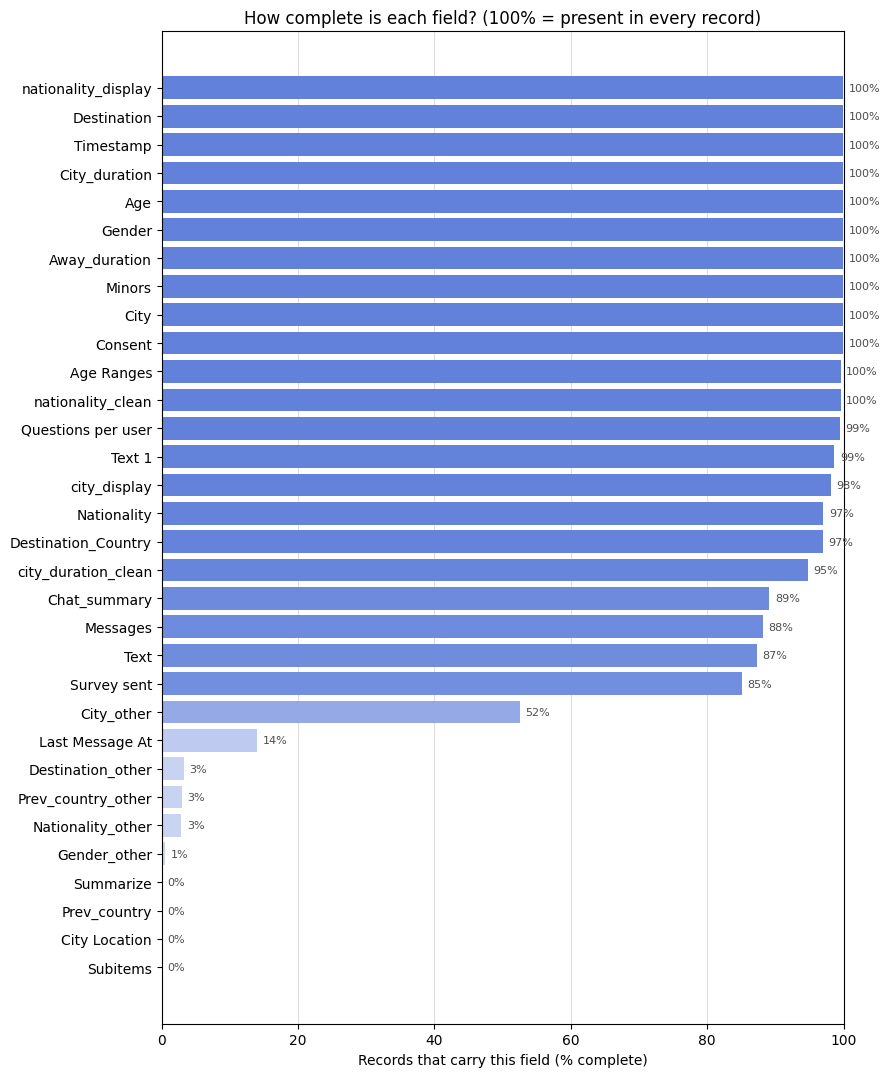

In [7]:
# Field completeness: share of records that DO carry each field (100% = every
# record has it). Only fields that are ever missing are shown -- the rest are
# fully complete. Longer / darker bar = more complete. Sorted least -> most
# complete so the gaps (the fields to worry about) sit at the top.
comp = (1 - df.isnull().mean()) * 100
comp = comp[comp < 100].sort_values()          # only fields with any gaps

fig, ax = plt.subplots(figsize=(9, max(3, len(comp) * 0.34)))
bars = ax.barh(comp.index, comp.values, color=seq_by_value(comp.values))
ax.bar_label(bars, labels=[f"{v:.0f}%" for v in comp.values],
             padding=4, fontsize=8, color=INK2)
ax.set_xlim(0, 100)
ax.set_xlabel('Records that carry this field (% complete)')
ax.set_ylabel('')
ax.grid(True, axis='x', color=GRID)
ax.set_axisbelow(True)
ax.set_title('How complete is each field? (100% = present in every record)')
plt.tight_layout()
plt.show()

### 1.3 MEAL survey — load & quality

**What this shows.** The second source: the MEAL feedback form. We rename its
long Spanish question headers to short codes, map the Likert usefulness scale to
1–5, and measure completeness and the **response rate** — only a small share of
chatbot users left feedback, so every satisfaction figure downstream is
indicative, not representative.

In [8]:
# Source spreadsheets: MEAL feedback form and chatbot interaction log
MEAL_PATH = '../data_&_docs/MMC_MEAL_1783087939.xlsx'
RESP_PATH = '../data_&_docs/MMC_bot_responses_1783087815.xlsx'

# header=2: the sheet has two banner rows above the real column headers
meal = pd.read_excel(MEAL_PATH, sheet_name='mmc-meal', header=2)
meal = meal.dropna(how='all').reset_index(drop=True)  # drop blank rows left by the banner

# Replace the long Spanish question text with short, code-friendly column names
meal.columns = [
    'Name', 'Timestamp',
    'usefulness_rating', 'would_recommend',
    'recommendation_text', 'discovery_channel', 'discovery_other',
]
meal['Timestamp'] = pd.to_datetime(meal['Timestamp'], errors='coerce')

# Map the Spanish Likert labels to a 1-5 numeric scale so we can average / trend
RATING_MAP = {
    'Muy útil': 5, 'Útil': 4,
    'Medianamente útil': 3, 'Poco útil': 2, 'Nada útil': 1,
}
meal['rating_num'] = meal['usefulness_rating'].map(RATING_MAP)

print(f"MEAL records: {len(meal)}")
meal.head(10)

MEAL records: 78


,Name,Timestamp,usefulness_rating,would_recommend,recommendation_text,discovery_channel,discovery_other,rating_num
0,whatsapp:+56929572884,2026-03-26 00:47:35.583000+00:00,Muy útil,Sí,Excelente,Recomendación de una ONG,NaN,5
1,whatsapp:+573113165608,2026-03-26 10:12:14.030000+00:00,Nada útil,Prefiero no responder,"Ayuda, no se cómo activar mi línea nueva Tigo ...",Otro,Redes sociales,1
2,whatsapp:+16462943119,2026-03-26 16:06:16.380000+00:00,Nada útil,Prefiero no responder,No recibí ninguna información.,Redes sociales,NaN,1
3,whatsapp:+573192311911,2026-03-27 03:36:50.975000+00:00,Medianamente útil,Prefiero no responder,No,Recomendación de una ONG,NaN,3
4,whatsapp:+16462943119,2026-03-27 11:47:53.350000+00:00,Nada útil,Prefiero no responder,No recibí información,Otro,Otro,1
5,whatsapp:+573123919181,2026-03-27 14:01:17.826000+00:00,Útil,Sí,Todo bien gracias 😌🫂,Recomendación de una ONG,NaN,4
6,whatsapp:+33766518156,2026-03-30 13:17:10.501000+00:00,Útil,Sí,no,Cartelera en un punto de atención,NaN,4
7,whatsapp:+573235746281,2026-04-06 15:25:56.376000+00:00,Muy útil,Prefiero no responder,no,Recomendación de otro migrante,NaN,5
8,whatsapp:+573043340252,2026-04-06 19:34:41.386000+00:00,Útil,Sí,NO,Cartelera en un punto de atención,NaN,4
9,whatsapp:+573009964262,2026-04-13 23:01:36.202000+00:00,Nada útil,Prefiero no responder,Ayudas en Bucaramanga,Recomendación de otro migrante,NaN,1


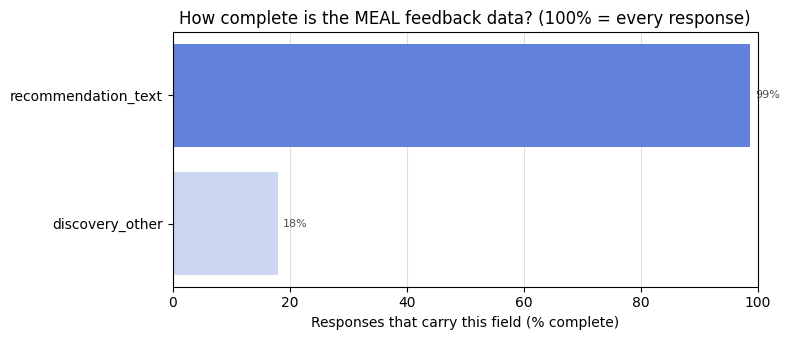

Total chatbot users (responses DB): 918
MEAL respondents:                   69
MEAL response rate:                 7.5%


In [9]:
# Field completeness for MEAL: share of responses that carry each field
# (100% = present in every response). Longer / darker = more complete.
comp = (1 - meal.isnull().mean()) * 100
comp = comp[comp < 100].sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
if len(comp):
    bars = ax.barh(comp.index, comp.values, color=seq_by_value(comp.values))
    ax.bar_label(bars, labels=[f"{v:.0f}%" for v in comp.values],
                 padding=4, fontsize=8, color=INK2)
else:
    ax.text(0.5, 0.5, 'All fields complete', ha='center', va='center', transform=ax.transAxes)
ax.set_xlim(0, 100)
ax.set_xlabel('Responses that carry this field (% complete)')
ax.grid(True, axis='x', color=GRID)
ax.set_axisbelow(True)
ax.set_title('How complete is the MEAL feedback data? (100% = every response)')
plt.tight_layout()
plt.show()

# How many chatbot users left MEAL feedback? (response rate)
resp_df = pd.read_excel(RESP_PATH, sheet_name='mmc bot - responses', header=2)
resp_df = resp_df.dropna(how='all').reset_index(drop=True)
total_users = resp_df['Name'].nunique()
meal_users = meal['Name'].nunique()
print(f"Total chatbot users (responses DB): {total_users}")
print(f"MEAL respondents:                   {meal_users}")
print(f"MEAL response rate:                 {meal_users / total_users * 100:.1f}%")

## 2. Who is the audience? — demographics

**What this shows.** A profile of *who* uses the chatbot — gender, age (as a
distribution and by generational cohort) and care responsibilities. Nationality
is part of this profile too, but because it is overwhelmingly one country it is
read on the origins map (Section 4) rather than as its own chart. Together these
test **H2**: a young, mostly Venezuelan user base.

### 2.1 Gender

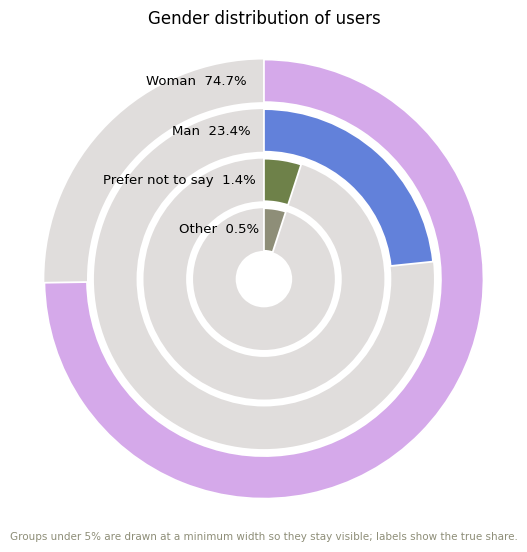

'Otro' breakdown (5 of 947 users):
  - 'Mujer'
  - 'Soy una mujer trans'
  - 'transgenero'
  - 'Gay'
  - 'lgtbQ+'


In [10]:
# Gender as a radial ("race track") bar chart: each category is a concentric
# ring, colour carries identity. The larger groups keep their true share as arc
# length; groups below MIN_FRAC are floored to that minimum width so they stay
# visible instead of vanishing to slivers -- labels always carry the true share.
GENDER_COLORS = {                       # explicit per-group colours (not by rank)
    'Woman': COLORES['ameba'],          # purple
    'Man': COLORES['agua'],             # blue
    'Prefer not to say': COLORES['arbol'],
    'Other': COLORES['madera'],
}
MIN_FRAC = 0.05                          # smallest arc a group can have (5% of circle)
gender = df['Gender'].value_counts()
gender.index = [en(GENDER_EN, k) for k in gender.index]   # English labels
gpct = gender / gender.sum() * 100
n = len(gender)

fig = plt.figure(figsize=(8, 5.6))
ax = fig.add_subplot(projection='polar')
ax.set_theta_zero_location('N')      # arcs start at 12 o'clock
ax.set_theta_direction(-1)           # ...and sweep clockwise
for i, (label, p) in enumerate(gpct.items()):
    r = n - i                        # outer ring = largest group
    frac = max(p / 100, MIN_FRAC)    # true share for big groups, floored for small
    ax.barh(r, 2 * np.pi, height=0.86, color=GRID, zorder=1)              # full track
    ax.barh(r, frac * 2 * np.pi, height=0.86,
            color=GENDER_COLORS.get(label, NEUTRAL),
            edgecolor=SURFACE, linewidth=1.3, zorder=3)                   # value arc
    ax.text(np.deg2rad(-5), r, f"{label}  {p:.1f}%",
            ha='right', va='center', fontsize=9.5, color=INK, zorder=5)
ax.set_ylim(0, n + 0.7)
ax.set_xticks([]); ax.set_yticks([])
ax.spines['polar'].set_visible(False)
ax.grid(False)
ax.set_title('Gender distribution of users', pad=16)
ax.text(0.5, -0.06, 'Groups under 5% are drawn at a minimum width so they stay visible; labels show the true share.',
        transform=ax.transAxes, ha='center', fontsize=7.5, color=MUTED)
plt.tight_layout()
plt.show()

# What does "Otro" actually mean? Surface the free-text each respondent typed.
otro_detail = df.loc[df['Gender'] == 'Otro', 'Gender_other'].dropna()
print(f"'Otro' breakdown ({len(otro_detail)} of {len(df)} users):")
for text in otro_detail:
    print(f"  - {text!r}")

### 2.2 Age

> **How to read it.** The bars show the share of users at each age; the smooth
> curve is a density estimate of the same distribution. The dashed and dotted
> lines mark the mean and median age.

> **Data-quality note (important).** Age is *self-reported* and Sami is an
> **adults-only (18+) service**, yet **36 records (3.8%)** report an age under
> 18 — and **28 of those are an impossible ≤12** (e.g. a "1-year-old" holding a
> conversation about legal documentation). The dedicated `Minors` (Si/No) field
> confirms these are *not* a child-count leaking into `Age`; they are simply
> unreliable self-reports. **Decision:** we keep every record for transparency
> but visually **flag the sub-18 band** so it is never read as a real cohort of
> minors. The "Generation Alpha (1–13)" bracket in the cohort chart below is
> almost entirely these bad self-reports and is greyed out, not deleted. A
> smaller, genuine signal sits inside this band — the 8 records aged 13–17 —
> which, if real, would be minors reaching an adults-only bot; that is a
> protection point worth raising with MMC rather than a demographic finding.

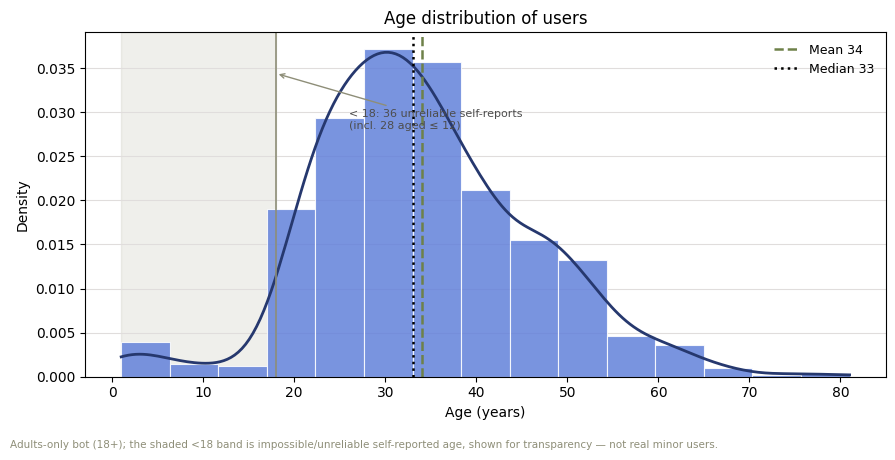

count    946.0
mean      34.1
std       11.9
min        1.0
25%       26.0
50%       33.0
75%       41.0
max       81.0


In [11]:
# Age profile: histogram (shape) with a smoothed density curve laid over it.
# Age is self-reported and the bot is adults-only (18+); the <18 band is flagged
# below as unreliable (see the data-quality note above), kept but not read as real.
age = df['Age'].dropna()
n_sub18 = int((age < 18).sum())
n_impossible = int((age <= 12).sum())

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(age, bins=15, density=True, color=PRIMARY,
        edgecolor=SURFACE, linewidth=0.8, alpha=0.85)
xs = np.linspace(age.min(), age.max(), 200)
ax.plot(xs, gaussian_kde(age)(xs), color=DARKBLUE, linewidth=2)
ax.axvline(age.mean(), color=COLORES['arbol'], linestyle='--', linewidth=1.8,
           label=f'Mean {age.mean():.0f}')
ax.axvline(age.median(), color=INK, linestyle=':', linewidth=1.8,
           label=f'Median {age.median():.0f}')

# Flag the sub-18 region: the bot is adults-only, so these are unreliable.
top = ax.get_ylim()[1]
ax.axvspan(age.min(), 18, color=COLORES['madera'], alpha=0.14, zorder=0)
ax.axvline(18, color=COLORES['madera'], linewidth=1.2)
ax.annotate(f'< 18: {n_sub18} unreliable self-reports\n(incl. {n_impossible} aged ≤ 12)',
            xy=(18, top * 0.88), xytext=(26, top * 0.72),
            fontsize=8, color=INK2,
            arrowprops=dict(arrowstyle='->', color=COLORES['madera'], lw=1))

ax.legend(fontsize=9, frameon=False)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.grid(True, axis='y', color=GRID)
ax.set_axisbelow(True)
ax.set_title('Age distribution of users')
fig.text(0.01, -0.03,
         'Adults-only bot (18+); the shaded <18 band is impossible/unreliable self-reported '
         'age, shown for transparency — not real minor users.',
         fontsize=7.5, color=MUTED, ha='left')
plt.tight_layout()
plt.show()
print(age.describe().round(1).to_string())

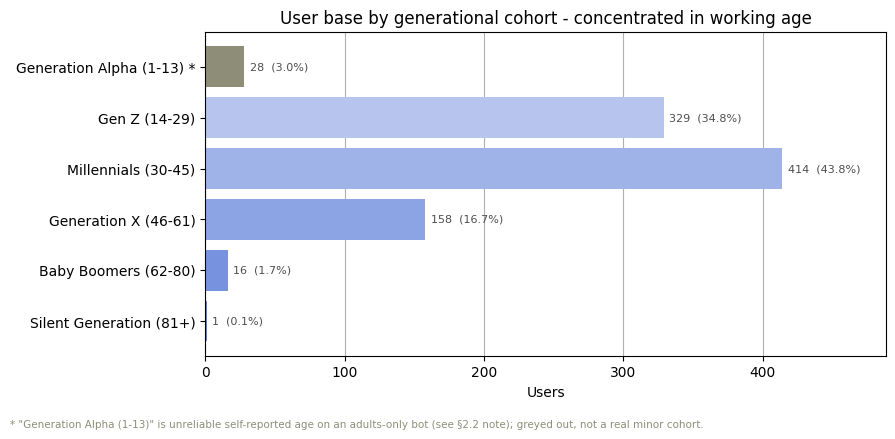

In [12]:
# User base by generational cohort. Bins follow the standard age brackets
# (as of 2025): Alpha 1-13, Gen Z 14-29, Millennials 30-45, Gen X 46-61,
# Baby Boomers 62-80, Silent 81+.
# NOTE: the "Generation Alpha (1-13)" cohort is almost entirely unreliable
# self-reports on an adults-only bot (see the data-quality note in §2.2). It is
# greyed out and asterisked here for transparency, not treated as a real cohort.
GEN_BINS = [0, 13, 29, 45, 61, 80, 200]
GEN_LABELS = [
    'Generation Alpha (1-13) *',
    'Gen Z (14-29)',
    'Millennials (30-45)',
    'Generation X (46-61)',
    'Baby Boomers (62-80)',
    'Silent Generation (81+)',
]
gen = pd.cut(df['Age'].dropna(), bins=GEN_BINS, labels=GEN_LABELS, right=True)
gc = gen.value_counts().reindex(GEN_LABELS).fillna(0).astype(int)
total = gc.sum()

# Blue ramp for the genuine adult cohorts; the flagged Alpha bar is greyed out.
bar_cols = seq_colors(len(gc))
bar_cols[0] = COLORES['madera']

fig, ax = plt.subplots(figsize=(9, 4.2))
bars = ax.barh(gc.index, gc.values, color=bar_cols)
ax.bar_label(bars, labels=[f"{v}  ({v/total*100:.1f}%)" for v in gc.values],
             padding=4, fontsize=8, color=INK2)
ax.invert_yaxis()                       # youngest cohort on top
ax.set_xlim(0, gc.values.max() * 1.18)
ax.set_xlabel('Users')
ax.grid(True, axis='x')
ax.set_axisbelow(True)
ax.set_title('User base by generational cohort - concentrated in working age')
fig.text(0.01, -0.03,
         '* "Generation Alpha (1-13)" is unreliable self-reported age on an adults-only bot '
         '(see §2.2 note); greyed out, not a real minor cohort.',
         fontsize=7.5, color=MUTED, ha='left')
plt.tight_layout()
plt.show()

### 2.3 Care responsibilities

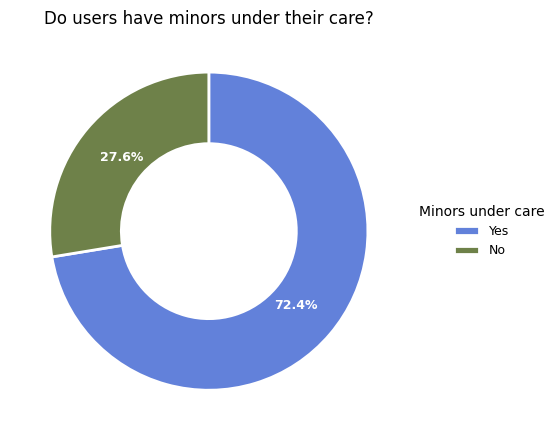

In [13]:
# How many users report having minors (children) under their care? Percentage
# on each wedge; the legend carries the category names only.
minors = df['Minors'].value_counts()
labels = [en(MINORS_EN, str(k)) for k in minors.index]  # English labels
fig, ax = plt.subplots(figsize=(6, 4.5))
wedges, _t, _a = ax.pie(
    minors.values, colors=cat_colors(len(minors)),
    autopct=pct_only_autopct(min_pct=1.0), pctdistance=0.72,
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor=SURFACE, linewidth=2),
    textprops=dict(fontsize=9, color=SURFACE, fontweight='bold'))
ax.legend(wedges, labels,
          title='Minors under care', loc='center left', bbox_to_anchor=(1.0, 0.5),
          fontsize=9, frameon=False)
ax.set_title('Do users have minors under their care?')
plt.tight_layout()
plt.show()

## 3. Geography — where are the users?

**What this shows.** Where the audience concentrates inside Colombia: the cities
with the most users, and the same counts aggregated to **departments** on a
choropleth map. Because the user base is 96% Venezuelan (Section 4), this also
shows *where Venezuelan migrants using Sami settle* (**H2**).

### 3.1 Cities — users per city

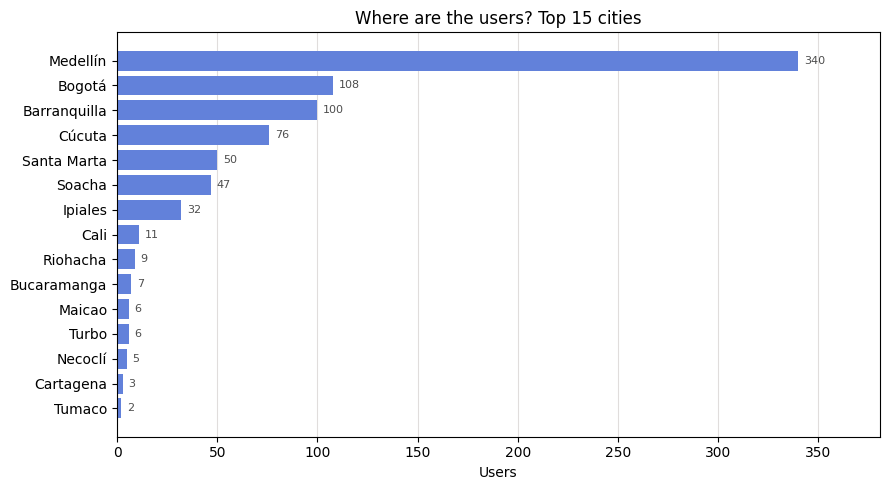

In [14]:
# Which cities have the most chatbot users? Where the audience concentrates.
# A single blue for every bar -- rank is already shown by the ordering.
city = df['city_display'].value_counts().head(15)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(city.index[::-1], city.values[::-1], color=PRIMARY)
ax.bar_label(bars, padding=4, fontsize=8, color=INK2)
ax.set_xlabel('Users')
ax.grid(True, axis='x', color=GRID)
ax.set_axisbelow(True)
ax.set_xlim(0, city.max() * 1.12)
ax.set_title('Where are the users? Top 15 cities')
plt.tight_layout()
plt.show()

### 3.2 User distribution across Colombia (map)

**What this shows.** Users aggregated to their **department** of residence and
drawn as a choropleth (darker blue = more users, log scale) over a real map of
Colombia. Built in two short steps — first map each free-text city to a
department and count, then colour the departments.

In [15]:
# Step 1 -- aggregate users to Colombian DEPARTMENTS. city_display is messy
# free-text (city names, misspellings, department suffixes), so a keyword matcher
# maps each entry to a department (ordered list, first hit wins). The top cities
# dominate but the long tail is captured too; only a handful stay unmapped.
def _dnorm(s):
    return unicodedata.normalize('NFKD', str(s)).encode('ascii', 'ignore').decode().lower()

# (keyword -> department). Order matters: specific cities before generic dept
# names; 'bogota' before 'soacha'/'cundinamarca' to resolve the Bogotá metro.
DEPT_KEYWORDS = [
    ('medellin', 'Antioquia'), ('necocli', 'Antioquia'), ('turbo', 'Antioquia'),
    ('apartado', 'Antioquia'), ('uraba', 'Antioquia'), ('currulao', 'Antioquia'),
    ('corrulao', 'Antioquia'), ('rionegro', 'Antioquia'), ('la ceja', 'Antioquia'),
    ('girardota', 'Antioquia'),
    ('barranquilla', 'Atlántico'), ('barraquilla', 'Atlántico'), ('galapa', 'Atlántico'),
    ('soledad', 'Atlántico'), ('malambo', 'Atlántico'), ('polonuevo', 'Atlántico'),
    ('sabanagrande', 'Atlántico'), ('santo tomas', 'Atlántico'), ('repelon', 'Atlántico'),
    ('cucuta', 'Norte de Santander'), ('tarra', 'Norte de Santander'),
    ('ocana', 'Norte de Santander'), ('tibu', 'Norte de Santander'),
    ('villa del rosario', 'Norte de Santander'),
    ('cartagena', 'Bolívar'), ('tiquisio', 'Bolívar'),
    ('santa marta', 'Magdalena'), ('sants marta', 'Magdalena'), ('sant marta', 'Magdalena'),
    ('cienaga', 'Magdalena'), ('magdalena', 'Magdalena'),
    ('cali', 'Valle del Cauca'), ('cartago', 'Valle del Cauca'), ('trujillo', 'Valle del Cauca'),
    ('valle del cauca', 'Valle del Cauca'),
    ('ipiales', 'Nariño'), ('tumaco', 'Nariño'), ('pasto', 'Nariño'), ('narino', 'Nariño'),
    ('riohacha', 'La Guajira'), ('maicao', 'La Guajira'), ('maikao', 'La Guajira'),
    ('carraipia', 'La Guajira'), ('guajira', 'La Guajira'),
    ('bucaramanga', 'Santander'), ('floridablanca', 'Santander'), ('piedecuesta', 'Santander'),
    ('santander', 'Santander'),
    ('pereira', 'Risaralda'), ('dosquebradas', 'Risaralda'), ('risaralda', 'Risaralda'),
    ('armenia', 'Quindío'), ('quindio', 'Quindío'),
    ('manizales', 'Caldas'), ('caldas', 'Caldas'),
    ('valledupar', 'Cesar'), ('cesar', 'Cesar'),
    ('monteria', 'Córdoba'), ('cordoba', 'Córdoba'),
    ('neiva', 'Huila'), ('huila', 'Huila'),
    ('sincelejo', 'Sucre'), ('ibague', 'Tolima'), ('tolima', 'Tolima'),
    ('popayan', 'Cauca'), ('cauca', 'Cauca'),
    ('quibdo', 'Chocó'), ('acandi', 'Chocó'), ('capurgana', 'Chocó'), ('jurado', 'Chocó'),
    ('choco', 'Chocó'),
    ('arauca', 'Arauca'), ('aguazul', 'Casanare'), ('yopal', 'Casanare'),
    ('mani ', 'Casanare'), ('casanare', 'Casanare'),
    ('carreno', 'Vichada'), ('vichada', 'Vichada'),
    ('restrepo', 'Meta'), ('villavicencio', 'Meta'), ('meta', 'Meta'),
    ('bogota', 'Bogota'), ('bogot', 'Bogota'), ('bobota', 'Bogota'),
    ('soacha', 'Cundinamarca'), ('suacha', 'Cundinamarca'), ('sohacha', 'Cundinamarca'),
    ('socha', 'Cundinamarca'), ('soscha', 'Cundinamarca'), ('zipaquira', 'Cundinamarca'),
    ('chia', 'Cundinamarca'), ('funza', 'Cundinamarca'), ('madrid', 'Cundinamarca'),
    ('silvania', 'Cundinamarca'), ('tocancipa', 'Cundinamarca'), ('puente piedra', 'Cundinamarca'),
    ('supata', 'Cundinamarca'), ('cundinamarca', 'Cundinamarca'),
    ('antioquia', 'Antioquia'), ('atlantico', 'Atlántico'),
]

def department_of(text):
    t = _dnorm(text)
    for kw, dep in DEPT_KEYWORDS:
        if kw in t:
            return dep
    return None

_dept_series = df['city_display'].dropna().map(department_of)
dept_ct = _dept_series.dropna().value_counts()
n_unmapped = int(_dept_series.isna().sum())

# Colombian departments (Natural Earth 1:10m admin-1 -- only this resolution has
# department-level detail) + neighbour countries (1:50m admin-0) for context.
_co_depts = [r for r in shapereader.Reader(shapereader.natural_earth(
    resolution='10m', category='cultural', name='admin_1_states_provinces_lakes')).records()
    if r.attributes.get('admin') == 'Colombia']
_neighbours = [r for r in shapereader.Reader(shapereader.natural_earth(
    resolution='50m', category='cultural', name='admin_0_countries')).records()
    if r.attributes.get('ADMIN') != 'Colombia']

print(f"Users mapped to a department: {int(dept_ct.sum())} / {len(df['city_display'].dropna())}"
      f"  (unmapped: {n_unmapped})")
dept_ct

Users mapped to a department: 916 / 929  (unmapped: 13)


city_display
Antioquia             364
Bogota                127
Atlántico             123
Norte de Santander     83
Cundinamarca           66
Magdalena              57
Nariño                 38
La Guajira             17
Valle del Cauca        13
Santander               9
Bolívar                 4
Chocó                   3
Risaralda               2
Cesar                   2
Casanare                2
Córdoba                 1
Huila                   1
Vichada                 1
Quindío                 1
Arauca                  1
Meta                    1
Name: count, dtype: int64

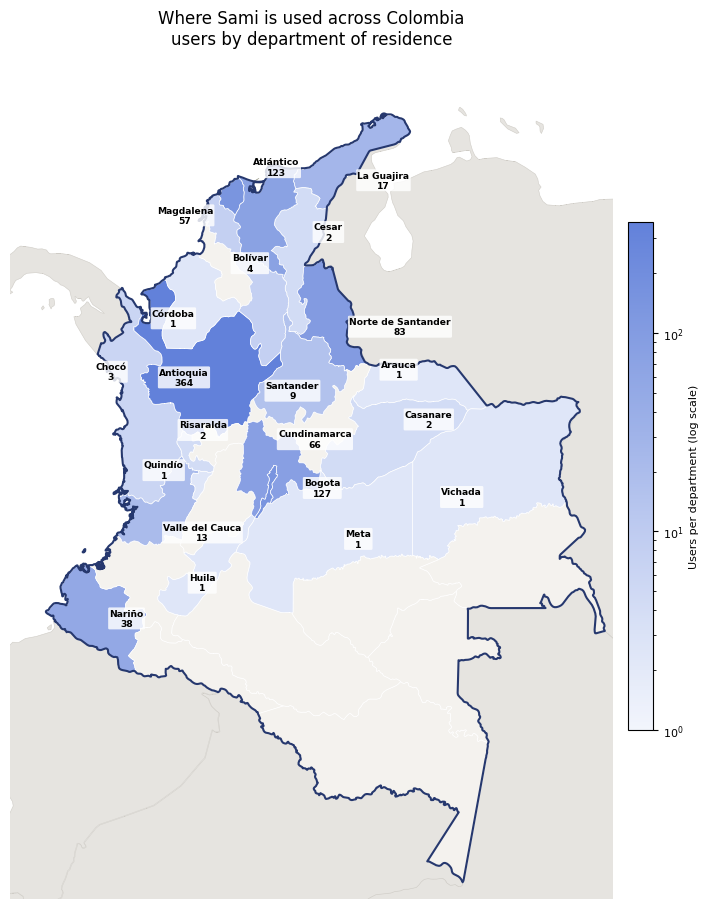

In [16]:
# Step 2 -- department choropleth. Each department is filled by its user count
# (log scale, so the smaller departments stay visible next to Antioquia); those
# with no users stay a neutral grey. A dark outline marks Colombia's national
# border, and labels (name + count) are auto-repelled so they don't overlap.
def _dept_key(s):
    return _dnorm(s).strip()
_dvals = {_dept_key(k): int(v) for k, v in dept_ct.items()}

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8.2, 9.2))
ax = fig.add_subplot(projection=proj)
ax.set_extent([-79.8, -66.7, -4.6, 13.8], crs=proj)
ax.set_facecolor(COLORES["cielo"])                 # sea

for r in _neighbours:                              # neighbour countries for context
    ax.add_geometries([r.geometry], proj, facecolor='#e6e4e0',
                      edgecolor='#cfccc6', linewidth=0.4, zorder=1)

norm = LogNorm(vmin=1, vmax=dept_ct.max())
label_pts = []
for r in _co_depts:
    name = r.attributes.get('name')
    users = _dvals.get(_dept_key(name), 0)
    ax.add_geometries([r.geometry], proj, edgecolor='white', linewidth=0.5, zorder=2,
                      facecolor=BLUE_CMAP(0.15 + 0.85 * norm(users)) if users else '#f4f2ee')
    if users:
        p = r.geometry.representative_point()
        label_pts.append((p.x, p.y, name, users))

# Well-defined national border: dissolve the departments into one outline.
_border = unary_union([r.geometry for r in _co_depts])
ax.add_geometries([_border], proj, facecolor='none', edgecolor=DARKBLUE,
                  linewidth=1.5, zorder=6)

# Labels: place at each department, then repel so none overlap (leader lines
# connect any that had to move).
texts = [
    ax.text(x, y, f"{name}\n{users}", transform=proj, fontsize=6.6, ha='center',
            va='center', color=INK, fontweight='bold', zorder=7,
            bbox=dict(boxstyle='round,pad=0.14', fc='white', alpha=0.82, ec='none'))
    for x, y, name, users in label_pts
]
adjust_text(texts, ax=ax, expand=(1.4, 1.6), force_text=(0.4, 0.6),
            arrowprops=dict(arrowstyle='-', color=MUTED, lw=0.5))

sm = plt.cm.ScalarMappable(cmap=BLUE_CMAP, norm=norm); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, fraction=0.035, pad=0.02, shrink=0.6)
cb.set_label('Users per department (log scale)', fontsize=8); cb.ax.tick_params(labelsize=8)
ax.set_title('Where Sami is used across Colombia\nusers by department of residence', fontsize=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Migration — origins, routes & timeline

**What this shows.** The migration journey: how long users have been away from
their country of origin (4.1), and a map of *where they came from* (nationality)
together with *where they intend to head next* (onward routes) (4.2) — testing
**H3**: a predominantly Venezuela → Colombia inflow, with a smaller onward
dispersion.

### 4.1 Time away from country of origin

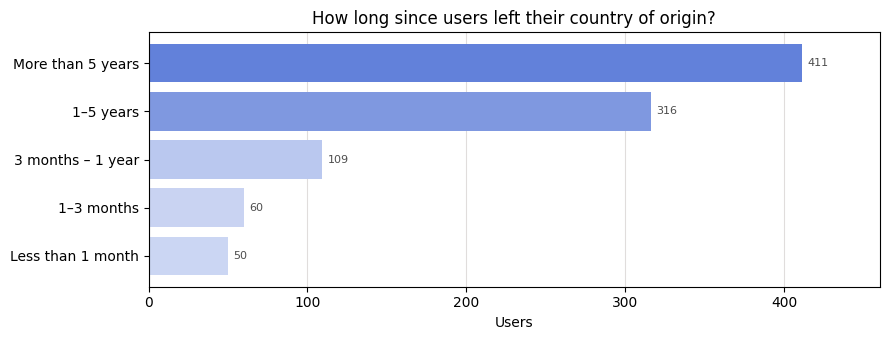

In [17]:
# How long has it been since users left their country of origin?
away = df['Away_duration'].value_counts()
away.index = [en(AWAY_EN, k) for k in away.index]  # English labels
away = away.reindex([b for b in AWAY_ORDER if b in away.index])
fig, ax = plt.subplots(figsize=(9, max(3.5, len(away) * 0.4)))
bars = ax.barh(away.index, away.values, color=seq_by_value(away.values))
ax.bar_label(bars, padding=4, fontsize=8, color=INK2)
ax.set_xlabel('Users')
ax.grid(True, axis='x', color=GRID)
ax.set_axisbelow(True)
ax.set_xlim(0, away.max() * 1.12)
ax.set_title('How long since users left their country of origin?')
plt.tight_layout()
plt.show()

### 4.2 Origins → here → onward (map)

**What this shows.** One Americas map that carries the whole migration story on a
single frame:

- **Origin (country fill).** Each country is shaded by how many users hold that
  nationality — a blue heatmap, light → dark. It reads on its own: **~96% of
  users are Venezuelan**, so Venezuela is the one dark shape and everywhere else
  stays pale.
- **Here (the Colombia hub).** *Every* user is currently in Colombia. The ring on
  Colombia marks that hub; its label reports how many intend to **stay**.
- **Onward (arrows).** Curved lilac arrows leave Colombia for each intended
  destination (width = users): the minority who plan to move on — mainly the
  **United States, Argentina and Chile** — plus a small return flow to Venezuela.

**Why it's built this way (and why the old banded-dot version was dropped).** The
dominant fact here is not movement but **settlement: 88% of users who stated a
destination intend to remain in Colombia (809 of 918)** — and a Colombia→Colombia
arrow cannot be drawn, so the previous
"proportional dots" map literally could not show the biggest group. The
origin→destination logic now reads directly: a Colombian national reporting
Colombia is staying put; a Venezuelan reporting Colombia is settling in the host
country; only the thin arrows are true onward migration. Counts first, then map.

In [18]:
# Step 1 -- nationality (origin) & onward-destination counts, matched to Natural
# Earth country polygons. Country names are normalized to NE / English spelling;
# the data itself is untouched.
NE_NAME = {   # our spelling -> Natural Earth ADMIN/NAME
    'Perú': 'Peru', 'Haití': 'Haiti', 'España': 'Spain', 'México': 'Mexico',
    'Panamá': 'Panama', 'Estados Unidos': 'United States of America',
    'United States': 'United States of America', 'Noruega': 'Norway',
}
DISP_NAME = {'United States of America': 'United States'}   # shorter on-map label

nat_ct = (df['nationality_clean'].dropna()
          .map(lambda s: NE_NAME.get(s, s)).value_counts())
dest_ct = (df['Destination_Country'].dropna()
           .map(lambda s: NE_NAME.get(str(s).strip(), str(s).strip())).value_counts())

# Natural Earth 1:110m countries (cartopy downloads & caches this on first run).
_recs = list(shapereader.Reader(shapereader.natural_earth(
    resolution='110m', category='cultural', name='admin_0_countries')).records())

def _find(name):
    for r in _recs:
        a = r.attributes
        if name in (a.get('ADMIN'), a.get('NAME'), a.get('NAME_LONG'), a.get('SOVEREIGNT')):
            return r
    return None

def _rep_point(country):
    p = _find(country).geometry.representative_point()
    return (p.x, p.y)

MAP_LON = (-125, -34)   # Americas frame; a few nationalities fall outside it
centroids = {c: _rep_point(c) for c in set(nat_ct.index) | set(dest_ct.index) if _find(c)}
off_map = [(c, int(n)) for c, n in nat_ct.items()
           if c in centroids and not (MAP_LON[0] < centroids[c][0] < MAP_LON[1])]

print("Nationalities:", nat_ct.to_dict())
print("Onward destinations:", dest_ct.to_dict())
print("Off-map nationalities:", off_map)

Nationalities: {'Venezuela': 908, 'Ecuador': 9, 'Cuba': 4, 'Colombia': 3, 'Peru': 3, 'Haiti': 2, 'United States of America': 2, 'Bulgaria': 2, 'Panama': 2, 'India': 1, 'Costa Rica': 1, 'Mexico': 1, 'Norway': 1, 'El Salvador': 1, 'Chile': 1, 'Nicaragua': 1, 'Argentina': 1}
Onward destinations: {'Colombia': 809, 'Venezuela': 60, 'United States of America': 24, 'Argentina': 18, 'Chile': 5, 'Ecuador': 1, 'Peru': 1}
Off-map nationalities: [('Bulgaria', 2), ('India', 1), ('Norway', 1)]


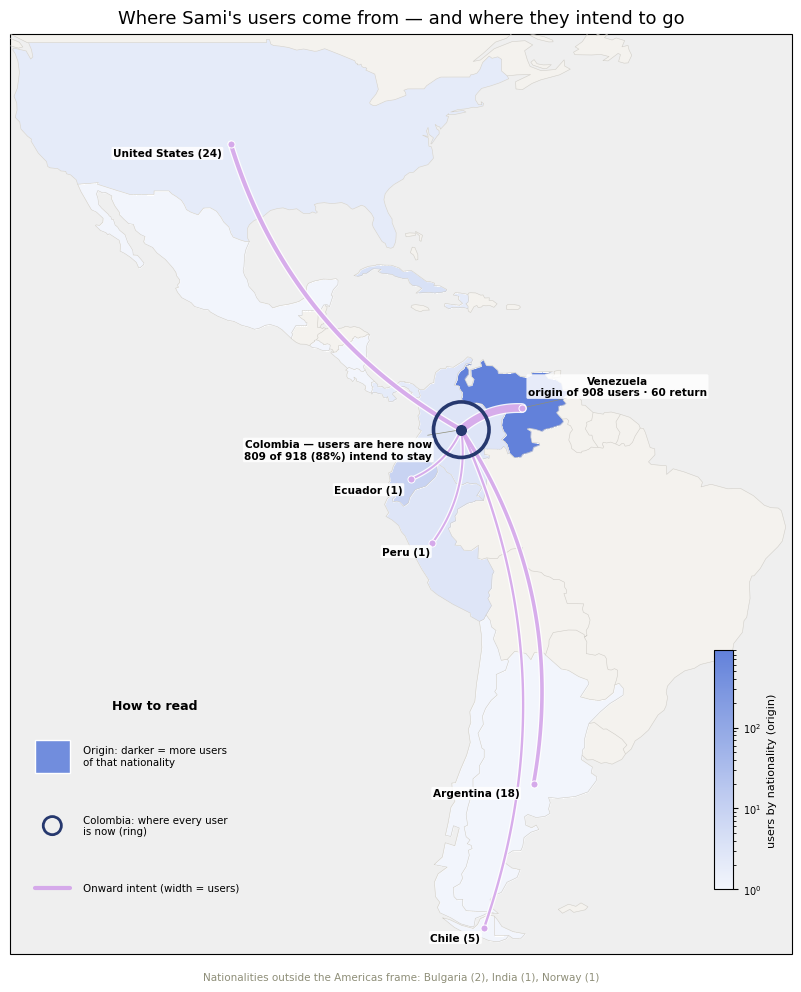

In [19]:
# Step 2 -- the origin -> here -> onward map (see the description above). Reuses
# the counts, centroids and helpers from Step 1. Origin = a choropleth of
# nationality (Venezuela dominates, so it reads on its own); Colombia = the
# current-location hub, ringed and labelled by how many intend to stay; lilac
# arrows = onward intentions, width scaled to users.
from matplotlib.colors import LogNorm

ROUTE = COLORES["ameba"]
proj  = ccrs.PlateCarree()

def _curved(p0, p1, rad=0.20, n=80):
    "Quadratic-Bezier arc between two lon/lat points (bows the routes)."
    p0, p1 = np.array(p0, float), np.array(p1, float)
    d = p1 - p0
    ctrl = (p0 + p1) / 2 + np.array([-d[1], d[0]]) * rad
    t = np.linspace(0, 1, n)[:, None]
    b = (1 - t) ** 2 * p0 + 2 * (1 - t) * t * ctrl + t ** 2 * p1
    return b[:, 0], b[:, 1]

fig = plt.figure(figsize=(9.2, 10))
ax = fig.add_subplot(projection=proj)
ax.set_extent([MAP_LON[0], MAP_LON[1], -57, 50], crs=proj)

# --- basemap ------------------------------------------------------------------
ax.add_feature(cfeature.OCEAN, facecolor=COLORES["cielo"], zorder=0)
ax.add_feature(cfeature.LAND,  facecolor="#f4f2ee", zorder=0)
ax.add_feature(cfeature.BORDERS,   linewidth=0.4, edgecolor="#cfccc6", zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.4, edgecolor="#cfccc6", zorder=3)

# --- ORIGIN choropleth: fill each nationality's country by user count ---------
onorm = LogNorm(vmin=1, vmax=nat_ct.max())
for c, n in nat_ct.items():
    r = _find(c)
    if r is None:
        continue
    ax.add_geometries([r.geometry], proj, edgecolor="white", linewidth=0.3,
                      facecolor=BLUE_CMAP(onorm(n)), zorder=1)

# --- ONWARD arrows: curved lilac routes from the Colombia hub ------------------
col    = centroids["Colombia"]
onward = {c: int(v) for c, v in dest_ct.items() if c != "Colombia" and c in centroids}
dmax   = max(onward.values())
for c, cnt in onward.items():
    xs, ys = _curved(col, centroids[c])
    lw = 1.4 + 4.0 * cnt / dmax
    ax.plot(xs, ys, transform=proj, color="white", linewidth=lw + 1.8,
            alpha=0.9, zorder=5, solid_capstyle="round")
    ax.plot(xs, ys, transform=proj, color=ROUTE, linewidth=lw,
            alpha=0.95, zorder=6, solid_capstyle="round")
    ax.scatter([centroids[c][0]], [centroids[c][1]], s=26, transform=proj,
               color=ROUTE, edgecolor="white", linewidth=0.7, zorder=7)

# --- HERE: the Colombia hub, ringed; direction of every arrow is "out of here" -
total = int(dest_ct.sum())
stay  = int(dest_ct.get("Colombia", 0))
ax.scatter([col[0]], [col[1]], s=1600, transform=proj, facecolor="none",
           edgecolor=DARKBLUE, linewidth=2.6, zorder=8)
ax.scatter([col[0]], [col[1]], s=48, transform=proj, color=DARKBLUE, zorder=9)

# --- labels: Colombia hub (with the stay headline), Venezuela origin, onward ---
# Venezuela is both the dominant origin AND a small return destination, so its
# label carries both facts and is not overwritten by the onward loop below.
labels = {"Colombia": f"Colombia — users are here now\n{stay} of {total} ({stay/total*100:.0f}%) intend to stay"}
_ven_ret = onward.get("Venezuela", 0)
labels["Venezuela"] = (f"Venezuela\norigin of {int(nat_ct.get('Venezuela', 0))} users"
                       + (f" · {_ven_ret} return" if _ven_ret else ""))
for c in onward:
    if c == "Venezuela":
        continue
    labels[c] = f"{DISP_NAME.get(c, c)} ({onward[c]})"
texts = []
for c, lab in labels.items():
    if c not in centroids:
        continue
    x, y = centroids[c]
    texts.append(ax.text(x, y, lab, transform=proj, fontsize=7.6, ha="center",
                         va="center", color=INK, fontweight="bold", zorder=11,
                         bbox=dict(boxstyle="round,pad=0.14", fc="white", alpha=0.85, ec="none")))
adjust_text(texts, ax=ax, expand=(1.3, 1.6), force_text=(0.3, 0.6),
            arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.5))

# --- legend: what the three marks mean ----------------------------------------
iax = ax.inset_axes([0.015, 0.03, 0.34, 0.26])
iax.set_xlim(0, 1); iax.set_ylim(0, 1); iax.axis("off")
iax.patch.set_facecolor("white"); iax.patch.set_alpha(0.85); iax.set_zorder(15)
iax.text(0.5, 0.95, "How to read", ha="center", va="top", fontsize=9,
         fontweight="bold", color=INK)
iax.add_patch(plt.Rectangle((0.05, 0.64), 0.13, 0.14, facecolor=BLUE_CMAP(0.9), ec="white"))
iax.text(0.23, 0.71, "Origin: darker = more users\nof that nationality",
         va="center", fontsize=7.4, color=INK)
iax.scatter([0.115], [0.42], s=170, facecolor="none", edgecolor=DARKBLUE, linewidth=2)
iax.text(0.23, 0.42, "Colombia: where every user\nis now (ring)", va="center",
         fontsize=7.4, color=INK)
iax.plot([0.05, 0.18], [0.16, 0.16], color=ROUTE, lw=3, solid_capstyle="round")
iax.text(0.23, 0.16, "Onward intent (width = users)", va="center",
         fontsize=7.4, color=INK)

# --- origin colourbar ---------------------------------------------------------
cax = ax.inset_axes([0.90, 0.07, 0.025, 0.26])
sm = plt.cm.ScalarMappable(norm=onorm, cmap=BLUE_CMAP); sm.set_array([])
cb = plt.colorbar(sm, cax=cax); cb.set_label("users by nationality (origin)", fontsize=8)
cb.ax.tick_params(labelsize=7)

# --- off-frame nationalities note ---------------------------------------------
if off_map:
    ax.text(0.5, -0.02, "Nationalities outside the Americas frame: "
            + ", ".join(f"{DISP_NAME.get(c, c)} ({n})" for c, n in off_map),
            transform=ax.transAxes, ha="center", va="top", fontsize=7.5, color=MUTED)

ax.set_title("Where Sami's users come from — and where they intend to go",
             fontsize=13, pad=8)
plt.tight_layout()
plt.show()